In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models

In [5]:
print("TensorFlow Version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPU FOUND" if gpus else "GPU NOT FOUND")

DATASET_PATH = "/content/drive/MyDrive/PlantVillage"
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 32
SEED = 42
EPOCHS = 30

TensorFlow Version: 2.20.0
GPU FOUND


In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.3,
    subset="training",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.3,
    subset="validation",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

temp_batches = tf.data.experimental.cardinality(temp_ds)
val_ds = temp_ds.take(temp_batches // 2)
test_ds = temp_ds.skip(temp_batches // 2)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
for idx, cls in enumerate(class_names):
    print(idx, cls)
print("\nNumber of Classes:", NUM_CLASSES)

Found 20638 files belonging to 15 classes.
Using 14447 files for training.
Found 20638 files belonging to 15 classes.
Using 6191 files for validation.
0 Pepper__bell___Bacterial_spot
1 Pepper__bell___healthy
2 Potato___Early_blight
3 Potato___Late_blight
4 Potato___healthy
5 Tomato_Bacterial_spot
6 Tomato_Early_blight
7 Tomato_Late_blight
8 Tomato_Leaf_Mold
9 Tomato_Septoria_leaf_spot
10 Tomato_Spider_mites_Two_spotted_spider_mite
11 Tomato__Target_Spot
12 Tomato__Tomato_YellowLeaf__Curl_Virus
13 Tomato__Tomato_mosaic_virus
14 Tomato_healthy

Number of Classes: 15


In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

'''print("\nComputing class weights...")
labels = []
for _, y in train_ds:
    labels.extend(y.numpy())
labels = np.array(labels)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights))
print(class_weights)'''

# Replace the slow label-looping code with this:
print("\nUsing pre-computed class weights...")

class_weights = {
    0: 1.3858033573141486, 1: 0.9451750081779522, 2: 1.347039627039627,
    3: 1.347039627039627, 4: 9.631333333333334, 5: 0.6534147444595205,
    6: 1.358439116125999, 7: 0.7050756466569058, 8: 1.4311045071817732,
    9: 0.7907498631636563, 10: 0.8288582903040734, 11: 0.9451750081779522,
    12: 0.4278690952169406, 13: 3.821957671957672, 14: 0.8926166203274637
}


Using pre-computed class weights...


In [8]:
def build_model():
    return models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        layers.Rescaling(1./255),
        data_augmentation,
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

model = build_model()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 459,983 (1.75 MB)

 Trainable params: 459,023 (1.75 MB)

 Non-trainable params: 960 (3.75 KB)

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
checkpoint = tf.keras.callbacks.ModelCheckpoint("best_cnn.keras", monitor="val_loss", save_best_only=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3, verbose=1)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/30
452/452 ━━━━━━━━━━━━━━━━━━━━ 126s 255ms/step - accuracy: 0.6459 - loss: 1.0667 - val_accuracy: 0.2091 - val_loss: 3.3456 - learning_rate: 0.0010
Epoch 2/30
452/452 ━━━━━━━━━━━━━━━━━━━━ 78s 173ms/step - accuracy: 0.7717 - loss: 0.6492 - val_accuracy: 0.2229 - val_loss: 5.0322 - learning_rate: 0.0010
Epoch 3/30
452/452 ━━━━━━━━━━━━━━━━━━━━ 71s 156ms/step - accuracy: 0.8240 - loss: 0.5018 - val_accuracy: 0.3557 - val_loss: 4.6261 - learning_rate: 0.0010
Epoch 4/30
452/452 ━━━━━━━━━━━━━━━━━━━━ 69s 152ms/step - accuracy: 0.8614 - loss: 0.3877 - val_accuracy: 0.5557 - val_loss: 1.9437 - learning_rate: 0.0010
Epoch 5/30
452/452 ━━━━━━━━━━━━━━━━━━━━ 68s 149ms/step - accuracy: 0.8946 - loss: 0.2984 - val_accuracy: 0.6653 - val_loss: 1.3062 - learning_rate: 0.0010
Epoch 6/30
452/452 ━━━━━━━━━━━━━━━━━━━━ 66s 146ms/step - accuracy: 0.9025 - loss: 0.2790 - val_accuracy: 0.4981 - val_loss: 2.7642 - learning_rate: 0.0010
Epoch 7/30
452/452 ━━━━━━━━━━━━━━━━━━━━ 68s 150ms/step - accuracy: 0.

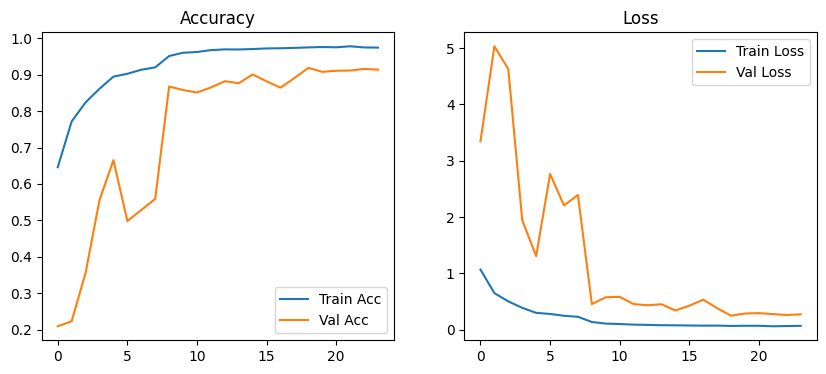

In [10]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")
plt.show()

In [11]:
test_loss, test_acc = model.evaluate(test_ds)
print("\nTest Accuracy:", test_acc)

y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

97/97 ━━━━━━━━━━━━━━━━━━━━ 324s 3s/step - accuracy: 0.9232 - loss: 0.2430

Test Accuracy: 0.9232264161109924



Classification Report

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.97      0.95      0.96       146
                     Pepper__bell___healthy       0.96      0.99      0.98       221
                      Potato___Early_blight       0.76      1.00      0.86       137
                       Potato___Late_blight       0.85      0.95      0.90       131
                           Potato___healthy       0.87      0.91      0.89        22
                      Tomato_Bacterial_spot       0.99      0.99      0.99       335
                        Tomato_Early_blight       0.94      0.90      0.92       144
                         Tomato_Late_blight       0.98      0.86      0.92       279
                           Tomato_Leaf_Mold       1.00      0.91      0.95       140
                  Tomato_Septoria_leaf_spot       0.97      0.92      0.95       275
Tomato_Spider_mites_Two_spotted_spider_m

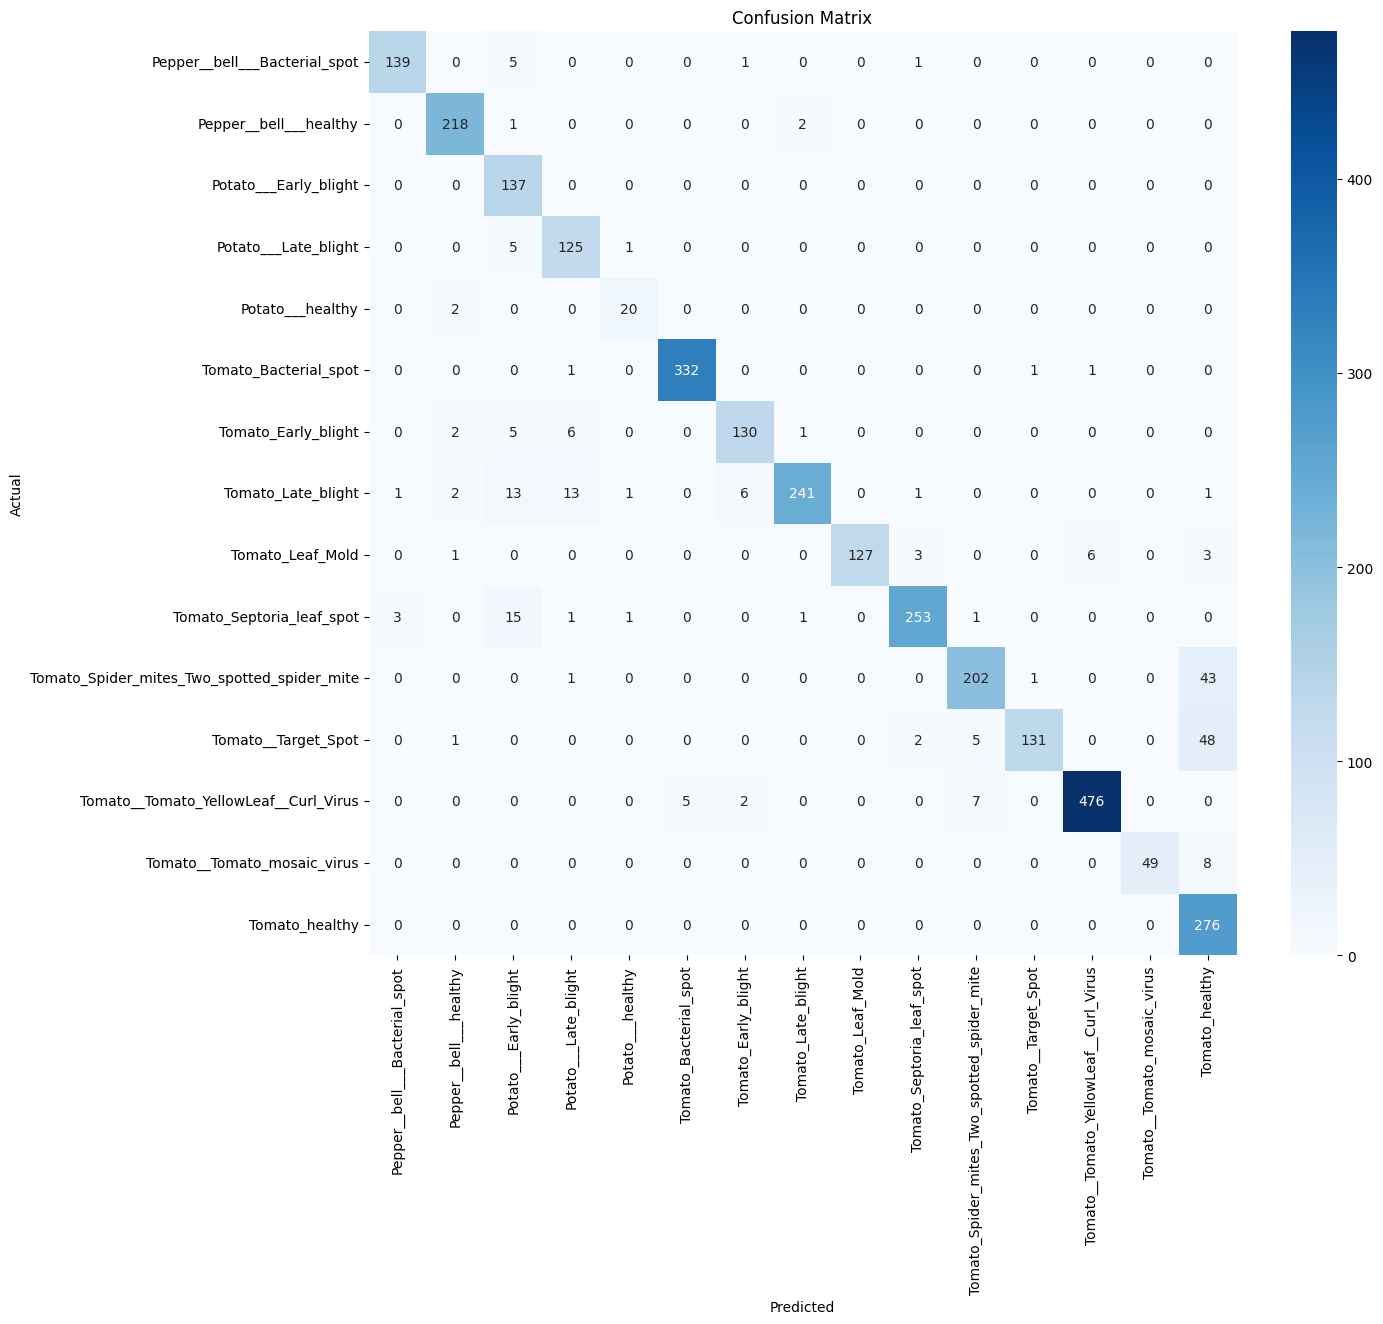


Model Saved Successfully


In [12]:
print("\nClassification Report\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

model.save("plant_disease_cnn_final.keras")
print("\nModel Saved Successfully")